In [1]:
%pip install scikit-learn pandas

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip available: 22.3.1 -> 26.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
%pip install --upgrade matplotlib pandas scikit-learn

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import PolynomialFeatures
from sklearn.ensemble import GradientBoostingRegressor

# Generate Graphs of Most Variables Against Popularity

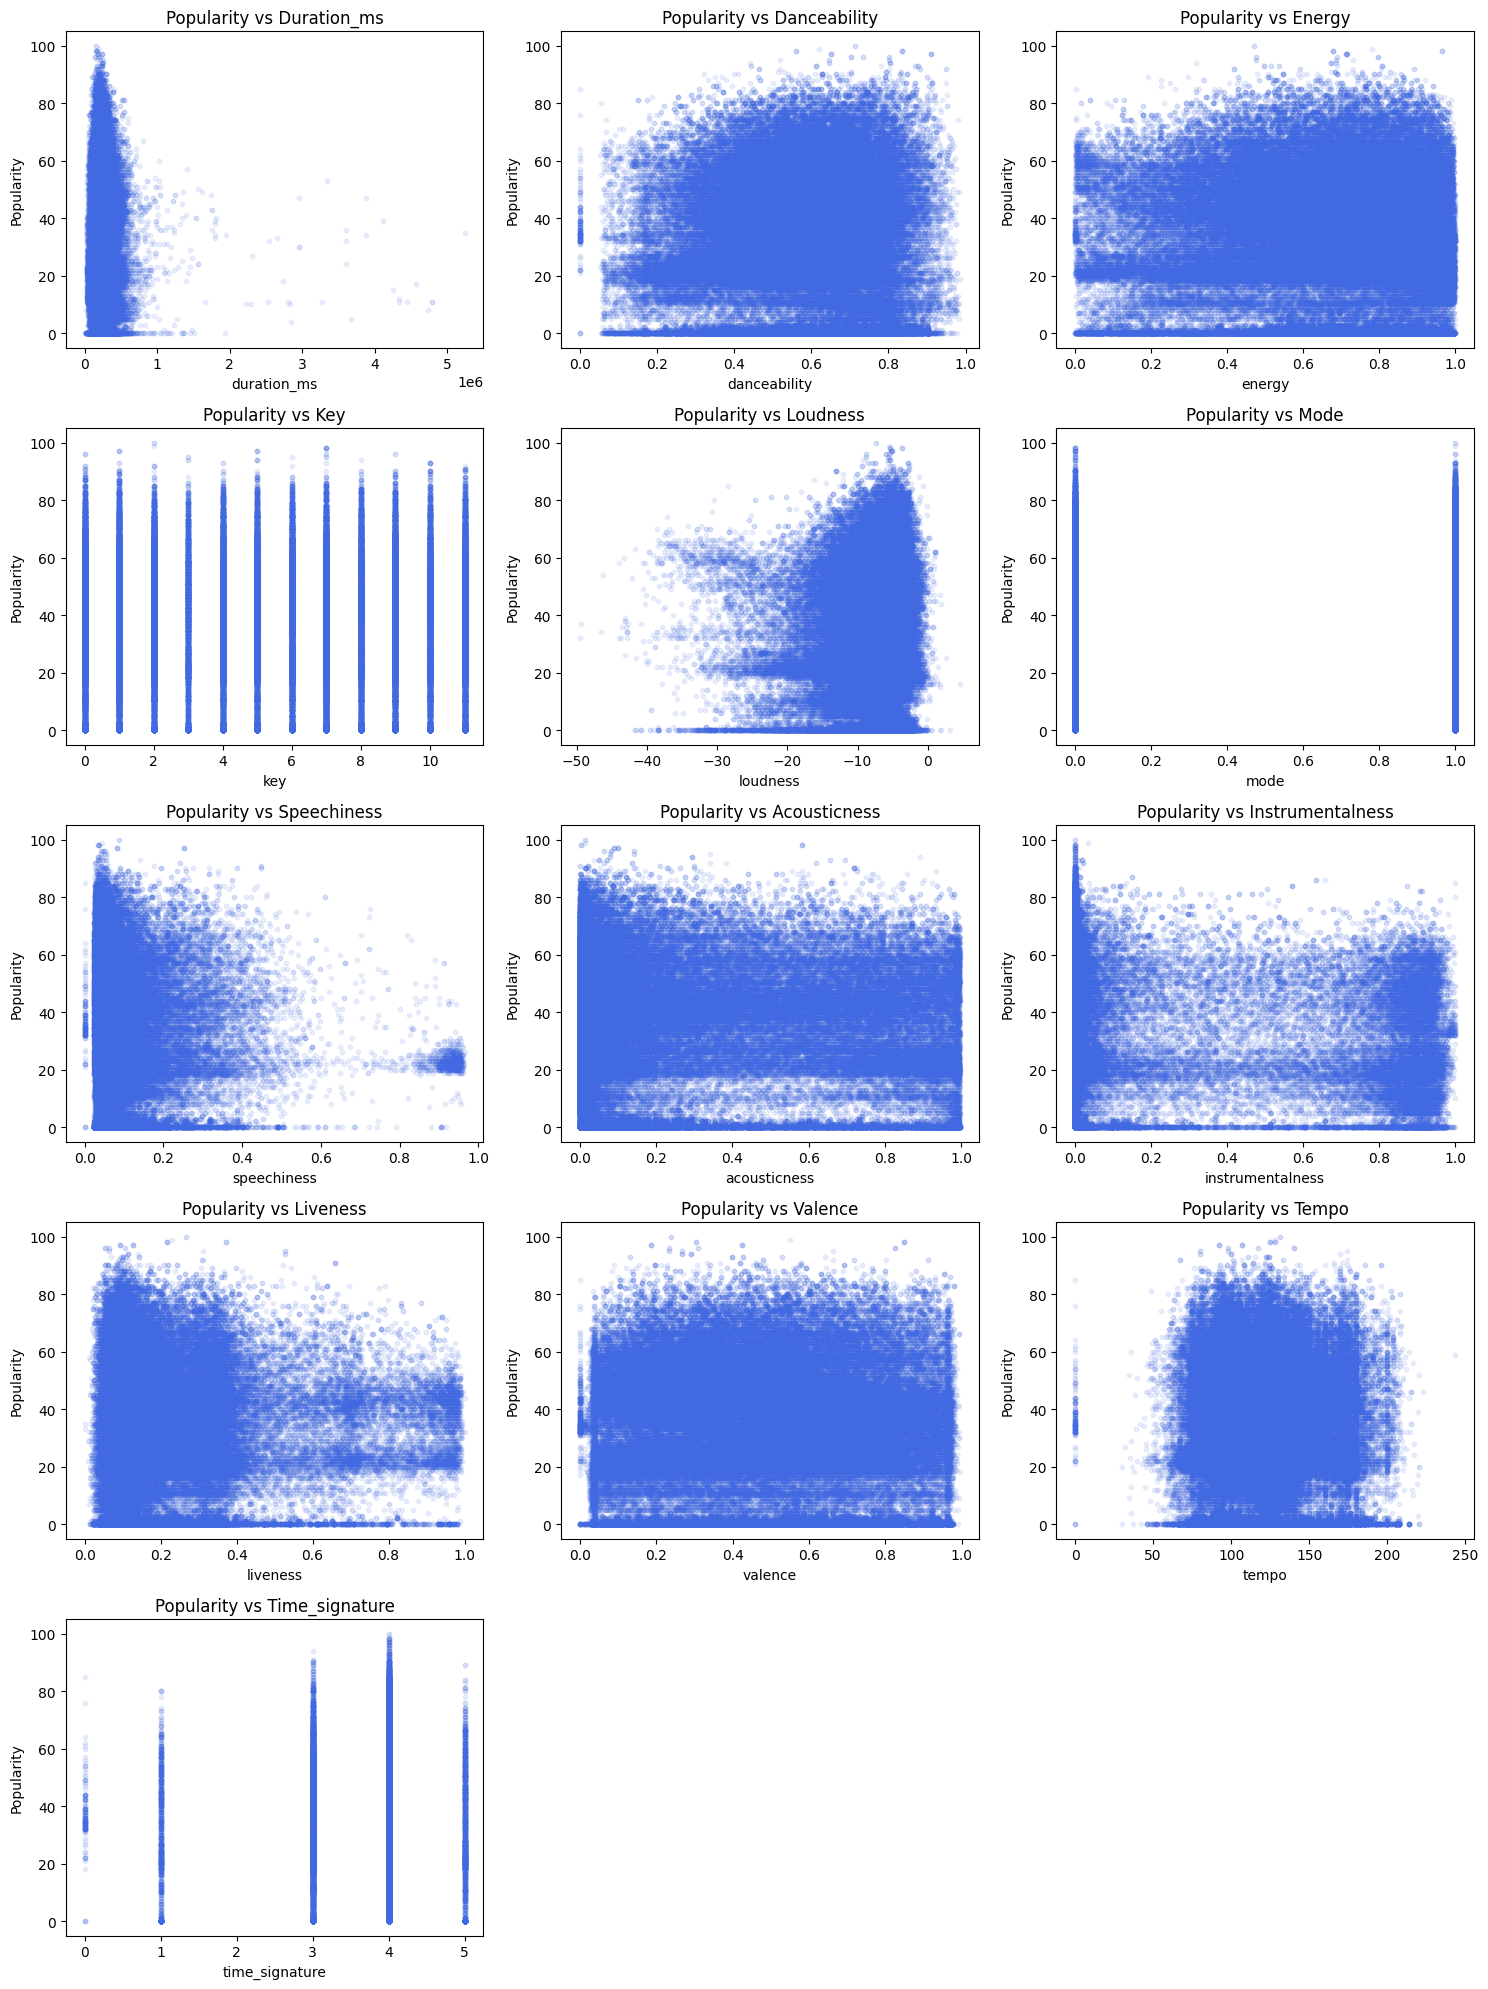

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
df = pd.read_csv('dataset.csv')

# 2. Automatically find all numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Remove 'popularity' from the list so we don't plot it against itself
# Also remove 'Unnamed: 0' if it's just an old index column
cols_to_exclude = ['popularity', 'Unnamed: 0']
features = [col for col in numerical_cols if col not in cols_to_exclude]

# 3. Set up a grid of subplots
num_features = len(features)
cols = 3  # Display 3 graphs per row
rows = (num_features + cols - 1) // cols  # Calculate how many rows are needed

fig, axes = plt.subplots(rows, cols, figsize=(15, 4 * rows))
axes = axes.flatten() # Flatten the grid so we can loop through it easily

# 4. Loop through each feature and create a scatter plot
for i, col in enumerate(features):
    axes[i].scatter(df[col], df['popularity'], alpha=0.1, s=10, color='royalblue')
    axes[i].set_title(f'Popularity vs {col.capitalize()}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Popularity')

# 5. Clean up any extra empty plots at the bottom of the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# 6. Display the graphs neatly
plt.tight_layout()
plt.show()

# Model 1: Linear Regression

## 1. Read in Dataset

In [ ]:
df = pd.read_csv('dataset.csv')
df.head(2)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic


In [ ]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre'],
      dtype='str')

## 2. Identify Inputs (X) and Output (y)


In [ ]:

X_columns = ['tempo', 'duration_ms', 'energy', 'danceability', 'acousticness', 'loudness', 'key', 'liveness', 'valence', 'instrumentalness']
y_column = 'popularity'

# Preprocessing: Convert selected X columns to numeric, coercing errors to NaN
for col in X_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Fill NaN values with the mean of the column
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

X = df[X_columns] # Input
y = df[y_column] # Output

print("Information about X columns after cleaning for Linear Regression model:")
X.info()


Information about X columns after cleaning for Linear Regression model:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   tempo             114000 non-null  float64
 1   duration_ms       114000 non-null  int64  
 2   energy            114000 non-null  float64
 3   danceability      114000 non-null  float64
 4   acousticness      114000 non-null  float64
 5   loudness          114000 non-null  float64
 6   key               114000 non-null  int64  
 7   liveness          114000 non-null  float64
 8   valence           114000 non-null  float64
 9   instrumentalness  114000 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 8.7 MB


In [ ]:
# X = df[['tempo', 'duration_ms']] # Input
# y = df['popularity'] # Output

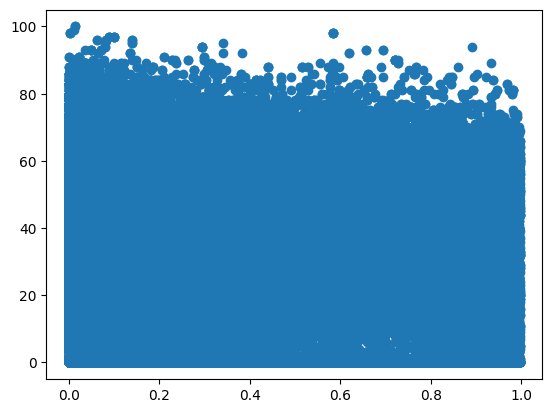

In [ ]:

plt.scatter(df['acousticness'],df['popularity'])

X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

## 3. Train the Model

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 4. Use Model to Predict

In [ ]:
model.predict(X_test)

array([35.18909587, 35.85992904, 33.84398821, ..., 32.85038675,
       37.02182449, 27.96758503], shape=(28500,))

## 5. Scoring our Model

In [ ]:
model.score(X_test, y_test)

0.020613419267900612

# Model 2: Random Forest

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html


## 1. Read in Dataset

In [ ]:
df = pd.read_csv('dataset.csv')
df.head(2)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic


## 2. Identify Inputs (X) and Output (y)

In [ ]:
X_columns = ['tempo', 'duration_ms', 'energy', 'danceability', 'acousticness', 'loudness', 'key', 'liveness', 'valence', 'instrumentalness']
y_column = 'popularity'
# Preprocessing: Convert selected X columns to numeric, coercing errors to NaN
for col in X_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Fill NaN values with the mean of the column
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

X = df[X_columns] # Input
y = df[y_column] # Output

print("Information about X columns after cleaning for Random Forest model:")
X.info()


Information about X columns after cleaning for Random Forest model:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   tempo             114000 non-null  float64
 1   duration_ms       114000 non-null  int64  
 2   energy            114000 non-null  float64
 3   danceability      114000 non-null  float64
 4   acousticness      114000 non-null  float64
 5   loudness          114000 non-null  float64
 6   key               114000 non-null  int64  
 7   liveness          114000 non-null  float64
 8   valence           114000 non-null  float64
 9   instrumentalness  114000 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 8.7 MB


## 3. Train the Model


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
model = RandomForestRegressor()

In [ ]:
model.fit(X_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

## 4. Use Model to Predict


In [ ]:
model.predict(X_test)

array([65.45      , 36.57555128, 31.341     , ..., 33.01      ,
        2.91304348, 67.78      ], shape=(28500,))

## 5. Scoring our Model


In [ ]:
model.score(X_train, y_train)

0.9034286315590518

# Model 3: Polynomial Regression

## 1. Read in Dataset

In [ ]:
df = pd.read_csv('dataset.csv')
df.head(2)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic


## 2. Identify Inputs (X) and Output (y)

In [ ]:
X_columns = ['tempo', 'duration_ms', 'energy', 'danceability', 'acousticness', 'loudness', 'key', 'liveness', 'valence', 'instrumentalness']
y_column = 'popularity'

# Preprocessing: Convert selected X columns to numeric, coercing errors to NaN
for col in X_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Fill NaN values with the mean of the column
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

X = df[X_columns] # Input
y = df[y_column] # Output

print("Information about X columns after cleaning for Linear Regression model:")
X.info()

Information about X columns after cleaning for Linear Regression model:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   tempo             114000 non-null  float64
 1   duration_ms       114000 non-null  int64  
 2   energy            114000 non-null  float64
 3   danceability      114000 non-null  float64
 4   acousticness      114000 non-null  float64
 5   loudness          114000 non-null  float64
 6   key               114000 non-null  int64  
 7   liveness          114000 non-null  float64
 8   valence           114000 non-null  float64
 9   instrumentalness  114000 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 8.7 MB


## 3. Train the Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
poly = PolynomialFeatures(degree = 2)
X_train_poly = poly.fit_transform(X_train)
X_test_poly = poly.transform(X_test)

In [ ]:
model = LinearRegression()

In [ ]:
model.fit(X_train_poly, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 4. Use Model to Predict

In [ ]:
model.predict(X_test_poly)

array([33.27051335, 31.59027671, 29.72936119, ..., 31.51971198,
       35.29438841, 38.24659977], shape=(28500,))

## 5. Scoring our Model

In [ ]:
model.score(X_test_poly, y_test)

0.022965476288760556

# Model 4: XG Boost

## 1. Read in Dataset

In [ ]:
df = pd.read_csv('dataset.csv')
df.head(2)

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,...,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,...,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic


## 2. Identify Inputs (X) and Output (y)

In [ ]:
X_columns = ['tempo', 'duration_ms', 'energy', 'danceability', 'acousticness', 'loudness', 'key', 'liveness', 'valence', 'instrumentalness']
y_column = 'popularity'
# Preprocessing: Convert selected X columns to numeric, coercing errors to NaN
for col in X_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    # Fill NaN values with the mean of the column
    if df[col].isnull().any():
        df[col] = df[col].fillna(df[col].mean())

X = df[X_columns] # Input
y = df[y_column] # Output

print("Information about X columns after cleaning for Random Forest model:")
X.info()

Information about X columns after cleaning for Random Forest model:
<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 10 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   tempo             114000 non-null  float64
 1   duration_ms       114000 non-null  int64  
 2   energy            114000 non-null  float64
 3   danceability      114000 non-null  float64
 4   acousticness      114000 non-null  float64
 5   loudness          114000 non-null  float64
 6   key               114000 non-null  int64  
 7   liveness          114000 non-null  float64
 8   valence           114000 non-null  float64
 9   instrumentalness  114000 non-null  float64
dtypes: float64(8), int64(2)
memory usage: 8.7 MB


## 3. Train the Model

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y)

In [ ]:
model = GradientBoostingRegressor()

In [ ]:
model.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

## 4. Use Model to Predict

In [ ]:
model.predict(X_test)

array([36.74380131, 34.4424197 , 19.13066799, ..., 40.0602712 ,
       37.96569705, 28.38635961], shape=(28500,))

## 5. Scoring our Model

In [ ]:
model.score(X_test, y_test)

0.08102280574207255